### CLASSIFICATION WITH SHAPELETS

In [5]:
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder
# from sktime.transformations.panel.shapelet_transform import RandomShapeletTransform, ShapeletTransform
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV
import numpy as np
import pandas as pd
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from tslearn.shapelets import ShapeletModel, grabocka_params_to_shapelet_size_dict
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns

ImportError: cannot import name 'runtime_version' from 'google.protobuf' (c:\Users\Gagia\anaconda3\envs\tslearn-env\lib\site-packages\google\protobuf\__init__.py)

In [ ]:
X_train = pd.read_csv("X_train.csv")
X_test = pd.read_csv("X_test.csv")

In [ ]:
y_train = pd.read_csv("y_train.csv")
y_test = pd.read_csv("y_test.csv")

In [ ]:
X_train = X_train.iloc[:, :100]
X_test = X_test.iloc[:, :100]
y_train = y_train.values.ravel()
y_test = y_test.values.ravel()

In [ ]:
scaler_ts = MinMaxScaler()
X_train_scaled = scaler_ts.fit_transform(X_train)
X_test_scaled = scaler_ts.transform(X_test)

In [ ]:
# Calcola shapelet_sizes con la funzione grabocka_params_to_shapelet_size_dict
shapelet_sizes = grabocka_params_to_shapelet_size_dict(
    n_ts=X_train_scaled.shape[0],
    ts_sz=X_train_scaled.shape[1],
    n_classes=len(np.unique(y_train)),
    l=0.1,    # lunghezza media shapelet = 10% della serie temporale
    r=10      # shapelet per classe
)

print("Shapelet sizes dict:", shapelet_sizes)


Shapelet sizes dict: {10: 5, 20: 5, 30: 5, 40: 5, 50: 5, 60: 5, 70: 4, 80: 4, 90: 4, 100: 3}


In [ ]:
shp_model = ShapeletModel(
    n_shapelets_per_size=shapelet_sizes,
    optimizer='adam',
    weight_regularizer=0.01,
    max_iter=100,
    random_state=42,
    verbose=1
)

shp_model.fit(X_train_scaled, y_train)
X_shp_train = shp_model.transform(X_train_scaled)
X_shp_test = shp_model.transform(X_test_scaled)

c:\Users\Gagia\anaconda3\envs\tslearn-env\lib\site-packages\tslearn\shapelets\shapelets.py:353: FutureWarning: The default value for 'scale' is set to False in version 0.4 to ensure backward compatibility, but is likely to change in a future version.
  warnings.warn("The default value for 'scale' is set to False "


Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - categorical_accuracy: 0.2070 - categorical_crossentropy: 1.6183 - loss: 1.7008
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - categorical_accuracy: 0.2070 - categorical_crossentropy: 1.6122 - loss: 1.6925
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - categorical_accuracy: 0.2070 - categorical_crossentropy: 1.6063 - loss: 1.6844
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - categorical_accuracy: 0.2070 - categorical_crossentropy: 1.6004 - loss: 1.6765
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - categorical_accuracy: 0.2097 - categorical_crossentropy: 1.5947 - loss: 1.6689
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - categorical_accuracy: 0.2097 - categorical_crossentropy: 1.5891 - loss: 1.6614
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - categorical_accuracy: 0.2279 - categorical_crossentropy: 1.5836 - loss: 1.6541
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - categorical_accuracy: 0.2288 - 

In [ ]:
# Addestra RandomForest SENZA TUNING
rf = RandomForestClassifier(random_state=42)
rf.fit(X_shp_train, y_train)

# Predizione
y_pred = rf.predict(X_shp_test)

# Valutazione
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00         3
         1.0       0.38      0.21      0.27        39
         2.0       0.45      0.67      0.54       116
         3.0       0.05      0.01      0.02        70
         4.0       0.53      0.59      0.56       113

    accuracy                           0.45       341
   macro avg       0.28      0.30      0.28       341
weighted avg       0.38      0.45      0.40       341



c:\Users\Gagia\anaconda3\envs\tslearn-env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Gagia\anaconda3\envs\tslearn-env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Gagia\anaconda3\envs\tslearn-env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", le

In [ ]:
clf = RandomForestClassifier(criterion= 'gini', max_depth= 10, max_features= 'log2', min_samples_leaf=2, 
                             min_samples_split= 10, n_estimators= 100, random_state=42,  class_weight='balanced')
clf.fit(X_shp_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       max_features='log2', min_samples_leaf=2,
                       min_samples_split=10, random_state=42)

In [ ]:
y_of = clf.predict(X_shp_train)

In [ ]:
print("train CR")
print(classification_report(y_train, y_of))

train CR
              precision    recall  f1-score   support

         0.0       0.88      1.00      0.93         7
         1.0       0.84      0.96      0.89        89
         2.0       0.81      0.91      0.85       271
         3.0       0.92      0.90      0.91       162
         4.0       0.95      0.80      0.87       264

    accuracy                           0.87       793
   macro avg       0.88      0.91      0.89       793
weighted avg       0.88      0.87      0.87       793



In [ ]:
y_pred = clf.predict(X_shp_test)

In [ ]:
print("test CR")
print(classification_report(y_test, y_pred))

test CR
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00         3
         1.0       0.42      0.33      0.37        39
         2.0       0.44      0.66      0.53       116
         3.0       0.21      0.13      0.16        70
         4.0       0.58      0.47      0.52       113

    accuracy                           0.45       341
   macro avg       0.33      0.32      0.32       341
weighted avg       0.43      0.45      0.43       341



c:\Users\Gagia\anaconda3\envs\tslearn-env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Gagia\anaconda3\envs\tslearn-env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Gagia\anaconda3\envs\tslearn-env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", le

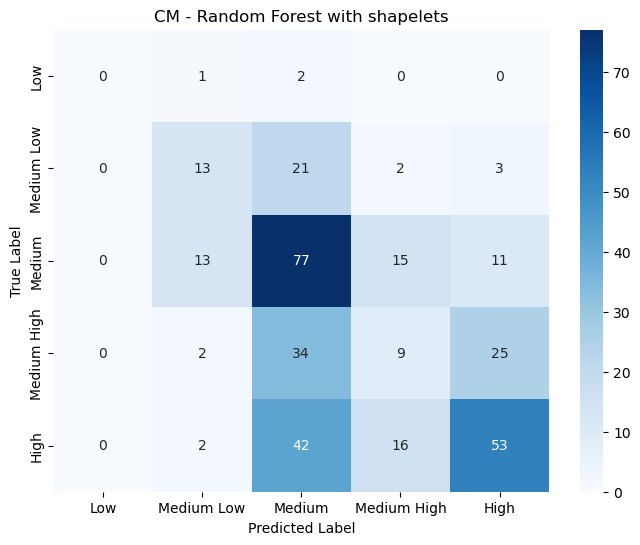

In [ ]:
from sklearn.metrics import confusion_matrix

# Calcola la confusion matrix
cm = confusion_matrix(y_test, y_pred)

labels = ["Low", "Medium Low", "Medium", "Medium High", "High"]

# Visualizza con heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('CM - Random Forest with shapelets')
plt.show()

In [ ]:
import joblib

# Salva il modello
joblib.dump(shp_model, "shp_model.pkl")

# Salva anche le trasformazioni se vuoi
joblib.dump(X_shp_train, "X_shp_train.pkl")
joblib.dump(X_shp_test, "X_shp_test.pkl")


['X_shp_test.pkl']

### Confronto con motifs

In [ ]:
import joblib

# Carica il modello
shp_model = joblib.load("shp_model.pkl")

# Carica le trasformazioni
X_shp_train = joblib.load("X_shp_train.pkl")
X_shp_test = joblib.load("X_shp_test.pkl")


ModuleNotFoundError: No module named 'google.protobuf'

In [ ]:
X_shp_train

array([[0.01517633, 0.00603118, 0.03500514, ..., 0.2201052 , 0.40081698,
        0.06213045],
       [0.01669256, 0.00232439, 0.03546577, ..., 0.27501842, 0.15065056,
        0.04634983],
       [0.01490606, 0.00121174, 0.0379828 , ..., 0.29247576, 0.18269311,
        0.02865412],
       ...,
       [0.01461126, 0.00141397, 0.03797007, ..., 0.29929423, 0.19553779,
        0.02726297],
       [0.01646729, 0.00131783, 0.04519477, ..., 0.3094899 , 0.19066192,
        0.0285561 ],
       [0.01379254, 0.01915898, 0.04697671, ..., 0.32499832, 0.1858477 ,
        0.04208748]], dtype=float32)

In [ ]:
importances = clf.feature_importances_
importances

array([0.04100143, 0.03088961, 0.02097947, 0.02228583, 0.02711015,
       0.01619671, 0.02282623, 0.01737969, 0.02835943, 0.01187206,
       0.03110211, 0.02802694, 0.01774925, 0.02533927, 0.01623642,
       0.01521253, 0.03518722, 0.02891274, 0.02072014, 0.02509873,
       0.02057541, 0.01619872, 0.01664573, 0.01997253, 0.01941769,
       0.03204959, 0.00960074, 0.01592039, 0.03123684, 0.01929721,
       0.02908839, 0.01852967, 0.01929869, 0.02390325, 0.01823822,
       0.01939261, 0.01390172, 0.02843311, 0.02456463, 0.01674443,
       0.02082568, 0.01318233, 0.02533487, 0.02840348, 0.01675815])

In [ ]:
indices = np.argsort(importances)[::-1]

# Stampa le prime 10 più importanti
for i in range(10):
    print(f"Shapelet {indices[i]} - Importance: {importances[indices[i]]:.4f}")

Shapelet 0 - Importance: 0.0410
Shapelet 16 - Importance: 0.0352
Shapelet 25 - Importance: 0.0320
Shapelet 28 - Importance: 0.0312
Shapelet 10 - Importance: 0.0311
Shapelet 1 - Importance: 0.0309
Shapelet 30 - Importance: 0.0291
Shapelet 17 - Importance: 0.0289
Shapelet 37 - Importance: 0.0284
Shapelet 43 - Importance: 0.0284


In [ ]:
cum_importances = np.cumsum(importances[indices])
n_top_shapelets = np.argmax(cum_importances >= 0.8) + 1  # quante shapelet bastano per spiegare l'80%

print(f"A livello globale, servono {n_top_shapelets} shapelet per spiegare l'80% della classificazione.")

A livello globale, servono 32 shapelet per spiegare l'80% della classificazione.


In [ ]:
import numpy as np

importances = clf.feature_importances_
indices = np.argsort(importances)[::-1]  # shapelet ordinate (decrescente)

def evaluate_with_topk_shapelets(X_train, y_train, X_test, y_test, indices, k):
    # prendi solo le prime k shapelet più importanti
    X_train_topk = X_train[:, indices[:k]]
    X_test_topk  = X_test[:, indices[:k]]
    
    # rialleniamo un nuovo RF con solo queste feature
    clf_k = RandomForestClassifier(random_state=42)
    clf_k.fit(X_train_topk, y_train)
    y_pred = clf_k.predict(X_test_topk)
    
    # report dettagliato per classe
    print(f"\n--- Risultati con top-{k} shapelet ---")
    print(classification_report(y_test, y_pred))

for k in [1, 3, 5, 10, 20]:
    evaluate_with_topk_shapelets(X_shp_train, y_train, X_shp_test, y_test, indices, k)


--- Risultati con top-1 shapelet ---
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00         3
         1.0       0.15      0.15      0.15        39
         2.0       0.36      0.34      0.35       116
         3.0       0.25      0.24      0.25        70
         4.0       0.41      0.42      0.41       113

    accuracy                           0.32       341
   macro avg       0.23      0.23      0.23       341
weighted avg       0.32      0.32      0.32       341


--- Risultati con top-3 shapelet ---
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00         3
         1.0       0.29      0.15      0.20        39
         2.0       0.40      0.58      0.48       116
         3.0       0.16      0.09      0.11        70
         4.0       0.53      0.54      0.53       113

    accuracy                           0.41       341
   macro avg       0.27      0.27      0.26       341
w

c:\Users\Gagia\anaconda3\envs\tslearn-env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Gagia\anaconda3\envs\tslearn-env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Gagia\anaconda3\envs\tslearn-env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", le


--- Risultati con top-5 shapelet ---
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00         3
         1.0       0.43      0.23      0.30        39
         2.0       0.41      0.58      0.48       116
         3.0       0.17      0.10      0.13        70
         4.0       0.51      0.51      0.51       113

    accuracy                           0.41       341
   macro avg       0.30      0.28      0.28       341
weighted avg       0.39      0.41      0.39       341


--- Risultati con top-10 shapelet ---
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00         3
         1.0       0.35      0.21      0.26        39
         2.0       0.44      0.63      0.52       116
         3.0       0.29      0.11      0.16        70
         4.0       0.54      0.58      0.56       113

    accuracy                           0.45       341
   macro avg       0.32      0.31      0.30       341


c:\Users\Gagia\anaconda3\envs\tslearn-env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Gagia\anaconda3\envs\tslearn-env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Gagia\anaconda3\envs\tslearn-env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", le


--- Risultati con top-20 shapelet ---
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00         3
         1.0       0.35      0.21      0.26        39
         2.0       0.44      0.63      0.52       116
         3.0       0.23      0.09      0.12        70
         4.0       0.52      0.58      0.55       113

    accuracy                           0.45       341
   macro avg       0.31      0.30      0.29       341
weighted avg       0.41      0.45      0.41       341



c:\Users\Gagia\anaconda3\envs\tslearn-env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Gagia\anaconda3\envs\tslearn-env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Gagia\anaconda3\envs\tslearn-env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", le


Analisi Shapelets:
Numero totale shapelets: 45


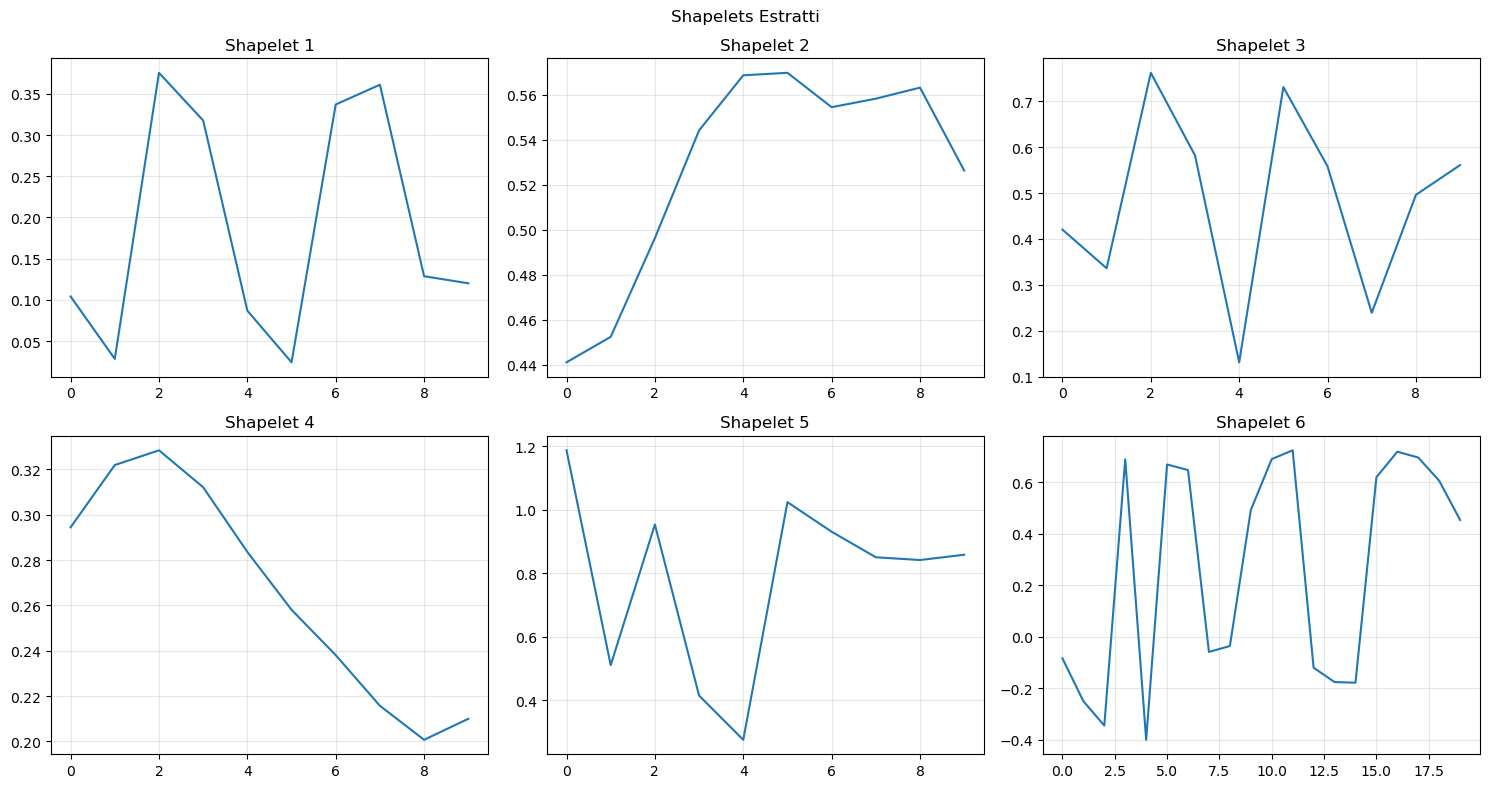

In [ ]:
# Plot alcuni shapelets rappresentativi ------------------------> non i top
shapelets = shp_model.shapelets_as_time_series_

print(f"\nAnalisi Shapelets:")
print(f"Numero totale shapelets: {len(shapelets)}")


n_plots = min(6, len(shapelets))
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i in range(n_plots):
    if i < len(shapelets):
        axes[i].plot(shapelets[i])
        axes[i].set_title(f'Shapelet {i+1}')
        axes[i].grid(True, alpha=0.3)
    else:
        axes[i].axis('off')

plt.suptitle('Shapelets Estratti')
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

# X_shp_train.shape = (n_samples, n_shapelets)
shapelet_idx = 0  # esempio
mean_dist_per_class = []
for c in np.unique(y_train):
    mean_dist_per_class.append(np.mean(X_shp_train[y_train==c, shapelet_idx]))
    
print(mean_dist_per_class)


[np.float32(0.015183915), np.float32(0.014930741), np.float32(0.015332905), np.float32(0.016025376), np.float32(0.01653942)]


Shapelet più rappresentativa della classe 1: 3


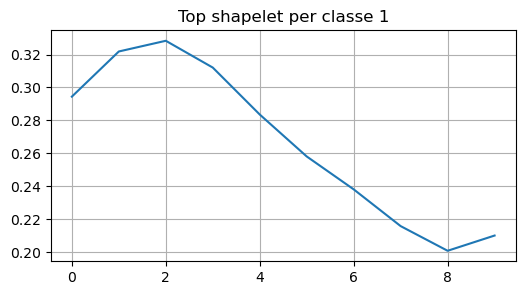

Shapelet più rappresentativa della classe 2: 3


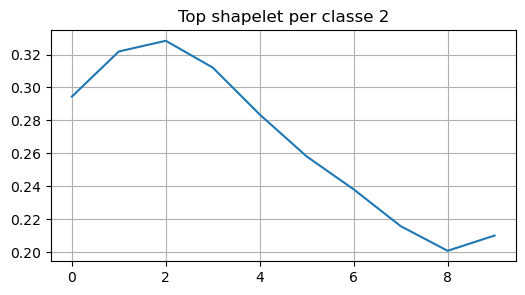

Shapelet più rappresentativa della classe 3: 3


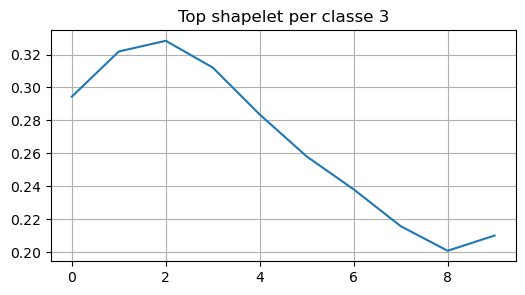

Shapelet più rappresentativa della classe 4: 3


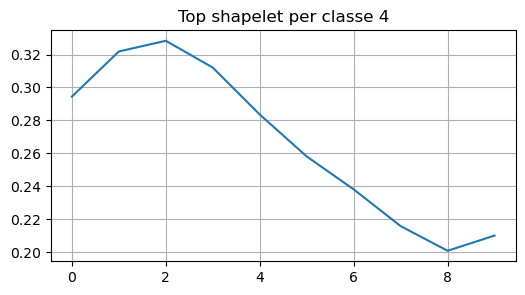

Shapelet più rappresentativa della classe 5: 0


c:\Users\Gagia\anaconda3\envs\tslearn-env\lib\site-packages\numpy\_core\fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\Gagia\anaconda3\envs\tslearn-env\lib\site-packages\numpy\_core\_methods.py:138: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


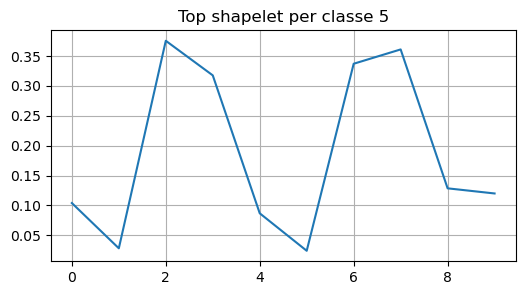

In [ ]:
for i in range(1, 6):

    class_idx = i
    # media delle distanze shapelet/class
    mean_dists = np.array([np.mean(X_shp_train[y_train==class_idx, i]) for i in range(X_shp_train.shape[1])])

    # la shapelet con distanza minima media
    top_shapelet_idx = np.argmin(mean_dists)
    print(f"Shapelet più rappresentativa della classe {class_idx}: {top_shapelet_idx}")

    plt.figure(figsize=(6, 3))
    plt.plot(shapelets[top_shapelet_idx])
    plt.title(f"Top shapelet per classe {class_idx}")
    plt.grid(True)
    plt.show()


Top 3 shapelets uniche per classe 1: [np.int64(3), np.int64(14), np.int64(30)]


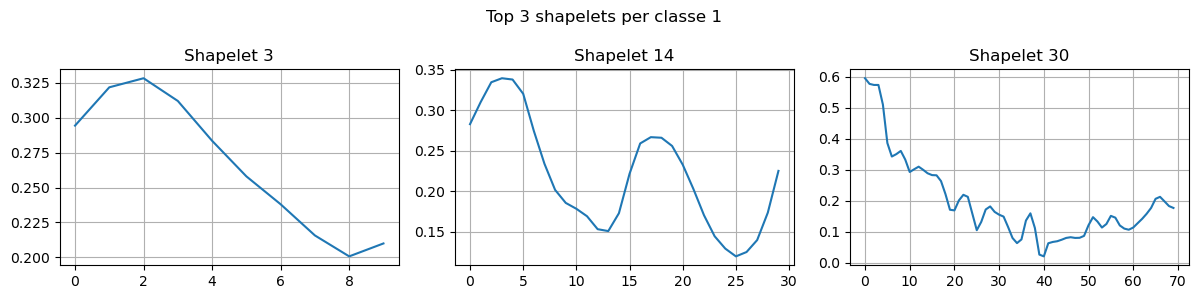

Top 3 shapelets uniche per classe 2: [np.int64(1), np.int64(13), np.int64(0)]


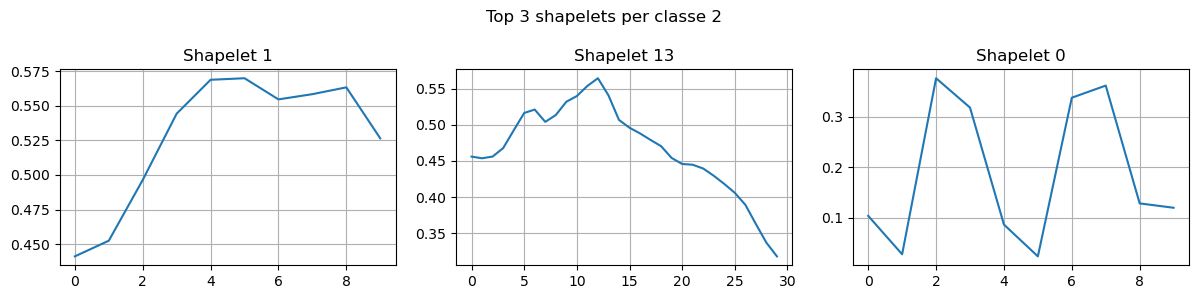

Top 3 shapelets uniche per classe 3: [np.int64(19), np.int64(7), np.int64(28)]


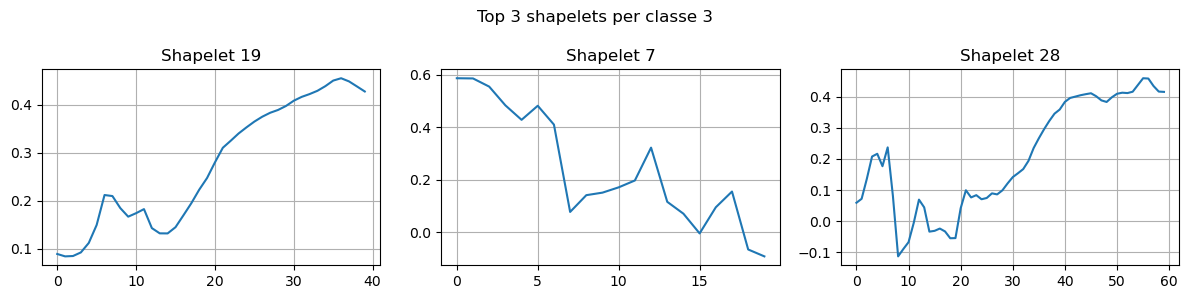

Top 3 shapelets uniche per classe 4: [np.int64(10), np.int64(17), np.int64(2)]


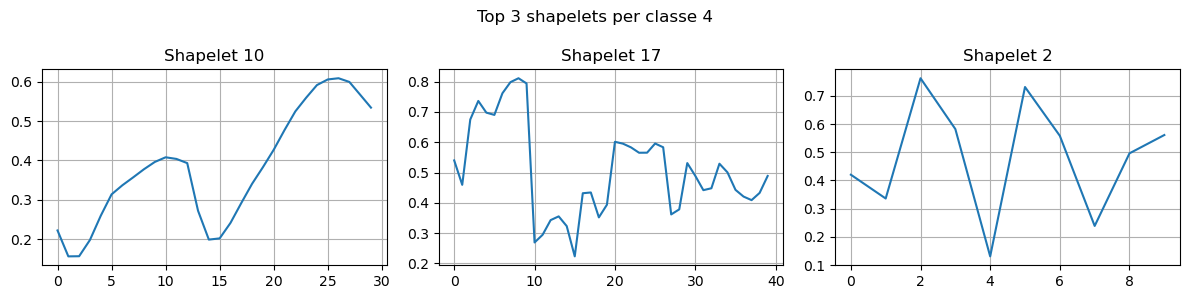

Top 3 shapelets uniche per classe 5: [np.int64(4), np.int64(5), np.int64(6)]


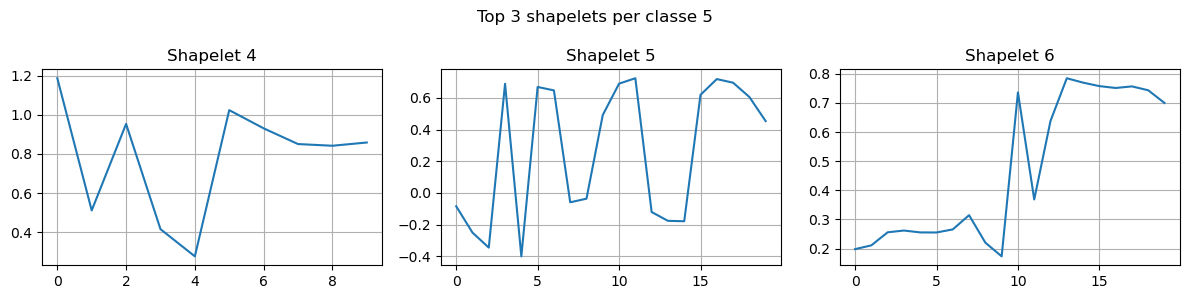

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Lista per tenere traccia delle shapelet già assegnate
used_shapelets = set()

# Ciclo sulle classi
for class_idx in range(1, 6):  # classi da 1 a 5
    # media delle distanze shapelet/class
    mean_dists = np.array([np.mean(X_shp_train[y_train==class_idx, i]) for i in range(X_shp_train.shape[1])])

    # ordina gli indici delle shapelet in base alla distanza media
    sorted_idx = np.argsort(mean_dists)

    # seleziona le prime 3 shapelet non ancora usate
    topk_idx = []
    for idx in sorted_idx:
        if idx not in used_shapelets:
            topk_idx.append(idx)
            used_shapelets.add(idx)
        if len(topk_idx) >= 3:
            break

    print(f"Top 3 shapelets uniche per classe {class_idx}: {topk_idx}")

    # plot delle top 3 shapelet
    plt.figure(figsize=(12, 3))
    for j, shp_idx in enumerate(topk_idx):
        plt.subplot(1, 3, j+1)
        plt.plot(shapelets[shp_idx])
        plt.title(f"Shapelet {shp_idx}")
        plt.grid(True)
    plt.suptitle(f"Top 3 shapelets per classe {class_idx}")
    plt.tight_layout()
    plt.show()



In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matrixprofile import compute, motifs
from dtaidistance import dtw

# Supponiamo di avere:
# X_train_scaled: serie temporali scalate
# y_train: etichette
# shapelets: lista di shapelet estratte
# topk_shapelets_per_class: lista dei topk shapelet indices per classe

def top_k_shapelets_per_class():
    for class_idx in range(1, 6):  # classi da 1 a 5
        # media delle distanze shapelet/class
        mean_dists = np.array([np.mean(X_shp_train[y_train==class_idx, i]) for i in range(X_shp_train.shape[1])])

        # ordina gli indici delle shapelet in base alla distanza media
        sorted_idx = np.argsort(mean_dists)

        # seleziona le prime 3 shapelet non ancora usate
        topk_idx = []
        for idx in sorted_idx:
            if idx not in used_shapelets:
                topk_idx.append(idx)
                used_shapelets.add(idx)
            if len(topk_idx) >= 3:
                break
        return topk_idx
    
topk_shapelets_per_class = top_k_shapelets_per_class()

topk = 3  # top 3 shapelet per classe
for class_idx in np.unique(y_train):
    print(f"\n=== Classe {class_idx} ===")
    
    # Seleziona tutte le serie della classe
    X_class = X_train_scaled[y_train == class_idx]
    
    # Lunghezza dei motif = lunghezza della shapelet più rappresentativa
    motif_len = shapelets[topk_shapelets_per_class[class_idx][0]].shape[0]
    
    # Concatenare tutte le serie della classe in un unico array
    ts_concat = np.concatenate(X_class)
    
    # Calcola il matrix profile
    mp = compute(ts_concat, windows=motif_len)
    
    # Estrai i top 3 motif
    motif_idxs = motifs(ts_concat, mp, max_motifs=3, radius=0.01)
    
    # Motif indices reali
    top3_motif_idx = [idx for idx, _ in motif_idxs]
    print(f"Top 3 motif start indices: {top3_motif_idx}")
    
    # Confronto DTW con top shapelet
    for shp_idx in topk_shapelets_per_class[class_idx]:
        shp = shapelets[shp_idx]
        print(f"\nShapelet {shp_idx}:")
        for motif_start in top3_motif_idx:
            motif = ts_concat[motif_start:motif_start+motif_len]
            distance = dtw.distance(shp, motif)
            print(f"DTW distance to motif starting at {motif_start}: {distance:.3f}")
            
            # Plot per confronto
            plt.figure(figsize=(6,3))
            plt.plot(shp, label='Shapelet')
            plt.plot(motif, label='Motif')
            plt.title(f"Classe {class_idx} - Shapelet {shp_idx} vs Motif {motif_start}")
            plt.legend()
            plt.show()


ImportError: cannot import name 'motifs' from 'matrixprofile' (c:\Users\Gagia\anaconda3\envs\tslearn-env\lib\site-packages\matrixprofile\__init__.py)

In [ ]:
# import stumpy

# # Per ogni classe
# motifs_per_class = {}
# for c in np.unique(y_train):
#     X_class = x_train[y_train == c]  # estrai solo le serie della classe
#     # calcola Matrix Profile su ciascuna serie (qui esempio su una sola serie per semplicità)
#     mp = stumpy.stump(T_A=X_class.iloc[0].values, m=7)
#     # seleziona gli indici con valori minimi del profile
#     top_k = 5 ############################################################################à
#     motifs_idx = np.argsort(mp.P_)[:top_k]
#     # estrai i motifs
#     motifs = [X_class.iloc[0, idx:idx+7].values for idx in motifs_idx]
#     motifs_per_class[c] = motifs


In [ ]:
# from dtaidistance import dtw

# results = []

# for c, motifs in motifs_per_class.items():
#     for motif_idx, motif in enumerate(motifs):
#         min_dist = np.inf
#         closest_shapelet = None
#         for s in top_shapelets:
#             # sliding window se shapelet più lunga del motif
#             L = len(motif)
#             shapelet_pattern = s.series
#             for start in range(len(shapelet_pattern) - L + 1):
#                 window = shapelet_pattern[start:start+L]
#                 dist = dtw.distance(window, motif)
#                 if dist < min_dist:
#                     min_dist = dist
#                     closest_shapelet = window
#         results.append({
#             "class": c,
#             "motif_idx": motif_idx,
#             "min_DTW_distance": min_dist,
#             "closest_shapelet_segment": closest_shapelet
#         })


In [ ]:
# import matplotlib.pyplot as plt

# for r in results:
#     plt.figure(figsize=(5,3))
#     plt.plot(r['closest_shapelet_segment'], label='Closest Shapelet')
#     plt.plot(motifs_per_class[r['class']][r['motif_idx']], label='Motif')
#     plt.title(f"Class {r['class']} - Motif {r['motif_idx']} vs Shapelet")
#     plt.legend()
#     plt.show()
